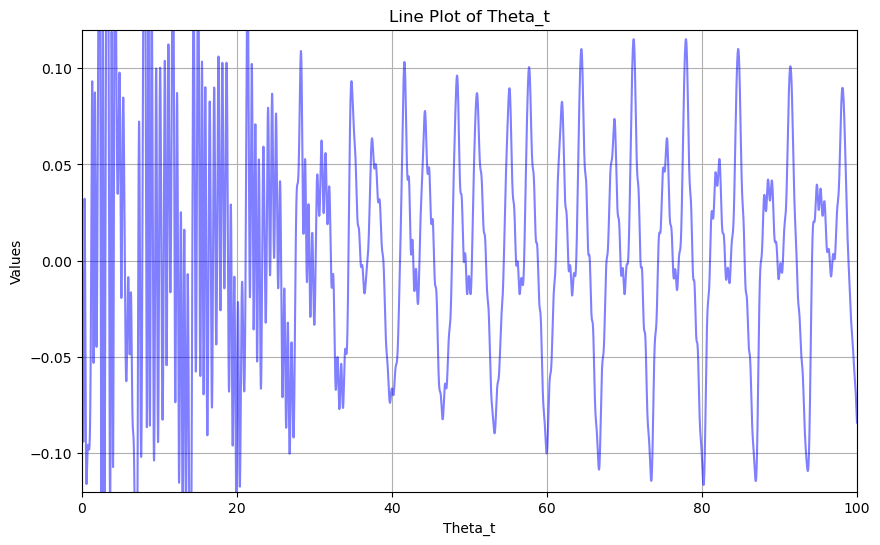

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
file_path = r'C:\Users\ss4432\study\theta_t - theta_t.csv'
data = pd.read_csv(file_path)

# Extracting the columns for plotting
x = data.iloc[:, 0]
y = data.iloc[:, 1]

# Creating the line plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, linestyle='-', color='b', alpha=0.5)
plt.xlim(0, 100)  # Adjusting the x-axis limit to focus on a smaller range similar to the provided image
plt.ylim(-0.12, 0.12)  # Adjusting the y-axis limit
plt.title('Line Plot of Theta_t')
plt.xlabel('Theta_t')
plt.ylabel('Values')
plt.grid(True)
plt.show()


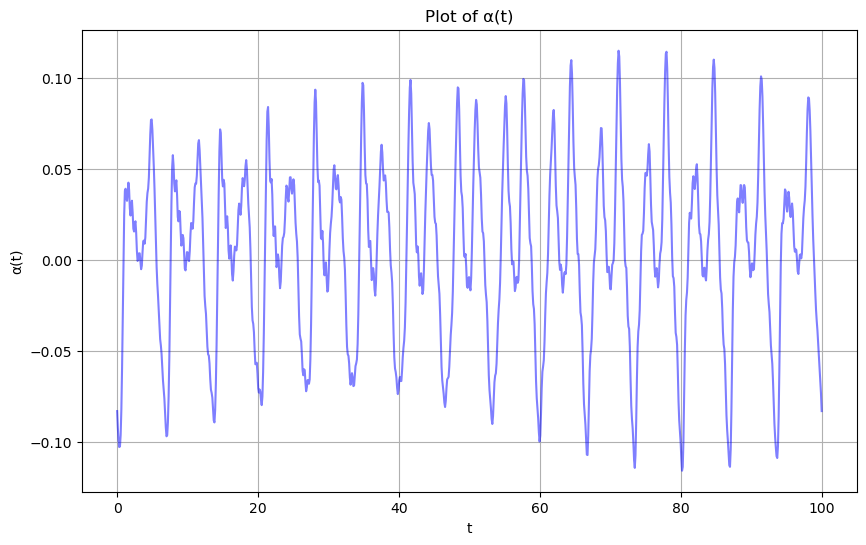

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
file_path = r'C:\Users\ss4432\study\theta_t - theta_t.csv'
data = pd.read_csv(file_path)
end_data = data.iloc[90000:].reset_index(drop=True)
input_data = np.array([[row[0] - 900, row[1]] for row in end_data.values])
interp = interp1d(input_data[:, 0], input_data[:, 1], kind='linear', fill_value="extrapolate")
def alpha(t):
    return interp(t)
t_values = np.linspace(0, 100, 1000)
alpha_values = alpha(t_values)

plt.figure(figsize=(10, 6))
plt.plot(t_values, alpha_values, linestyle='-', color='b', alpha=0.5)
plt.title('Plot of α(t)')
plt.xlabel('t')
plt.ylabel('α(t)')
plt.grid(True)
plt.show()


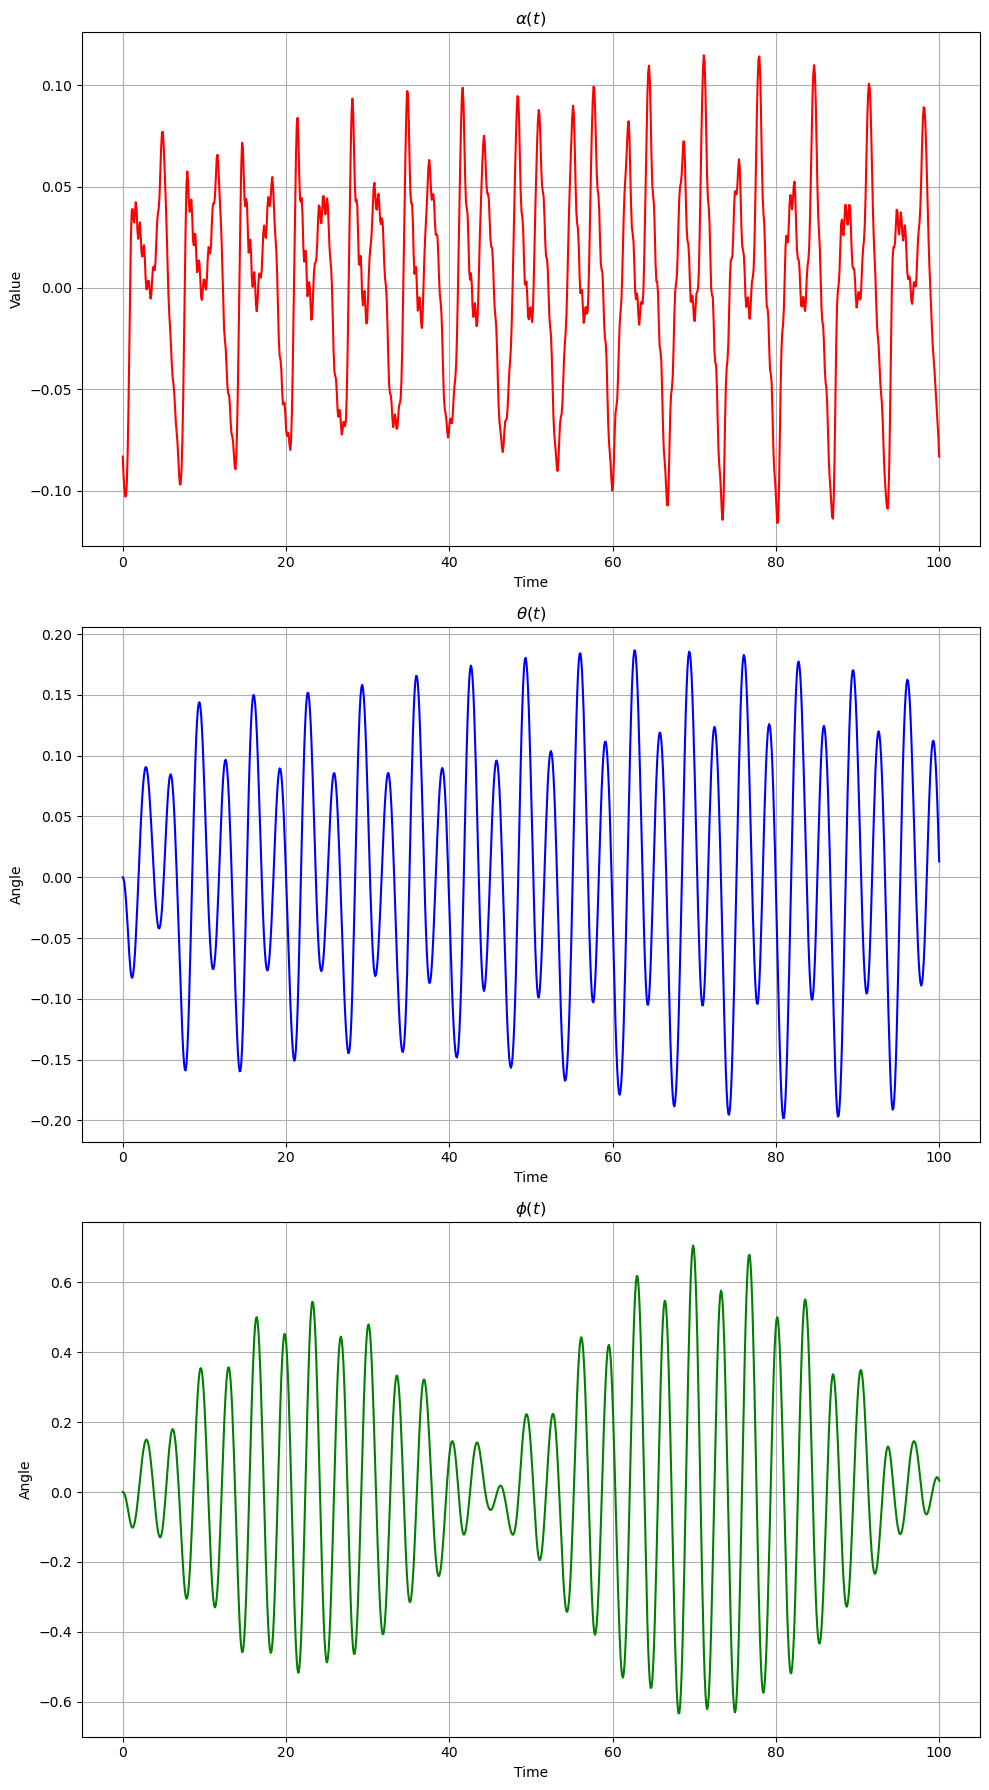

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import pandas as pd

# Load the data
file_path = r'C:\Users\ss4432\study\theta_t - theta_t.csv'
data = pd.read_csv(file_path)

# Extract the relevant part of the data
end_data = data.iloc[90000:].reset_index(drop=True)
input_data = np.array([[row[0] - 900, row[1]] for row in end_data.values])

# Create an interpolation function
interp = interp1d(input_data[:, 0], input_data[:, 1], kind='linear', fill_value="extrapolate")

# Define the alpha function
def alpha(t):
    return interp(t)

# Define the parameters
a = 1
b = 0.9
c = 0.1
M = 10
m = 1
II = 10
g = 10
omega = 2 * np.pi * 0.3
k = 100
EE = 0.000001
d = 6
theta_max = 0.3
C1 = 10
lambda_phi = 0.0003

# Dimensionless parameters
m1 = m / M
II1 = II / (M * a**2)
g1 = g / (a * omega**2)
k1 = k / (M * a**2 * omega**2)
EE1 = EE / (M * a**2 * omega**2)
nu1 = C1 / (M * a**2 * omega)
lambda1 = lambda_phi / (M * a**2 * omega)
b1 = b / a
c1 = c / a

# Potential energy function
def U(theta):
    return EE1 * (1 / (theta - theta_max)**d + 1 / (theta + theta_max)**d)

# Define the system of ODEs
def system(t, y):
    theta, phi, theta_dot, phi_dot = y
    
    # Calculate the second derivatives based on the provided equations
    d2theta = (-m1 * g1 * np.sin(theta) - k1 * (theta - alpha(t)) - nu1 * theta_dot) / II1
    d2phi = (-m1 * g1 * np.sin(phi) - k1 * (phi - alpha(t)) - lambda1 * phi_dot) / II1
    
    return [theta_dot, phi_dot, d2theta, d2phi]

# Initial conditions
ics = [0, 0, 0, 0]

# Time points
t_span = (0, 100)
t_values = np.linspace(*t_span, 1000)

# Solve the system
sol = solve_ivp(system, t_span, ics, t_eval=t_values, method='RK45', vectorized=True)

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot alpha(t)
axs[0].plot(t_values, alpha(t_values), color='red')
axs[0].set_title(r'$\alpha(t)$')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Value')
axs[0].grid(True)

# Plot theta(t)
axs[1].plot(sol.t, sol.y[0], color='blue')
axs[1].set_title(r'$\theta(t)$')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Angle')
axs[1].grid(True)

# Plot phi(t)
axs[2].plot(sol.t, sol.y[1], color='green')
axs[2].set_title(r'$\phi(t)$')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Angle')
axs[2].grid(True)

plt.tight_layout()
plt.show()


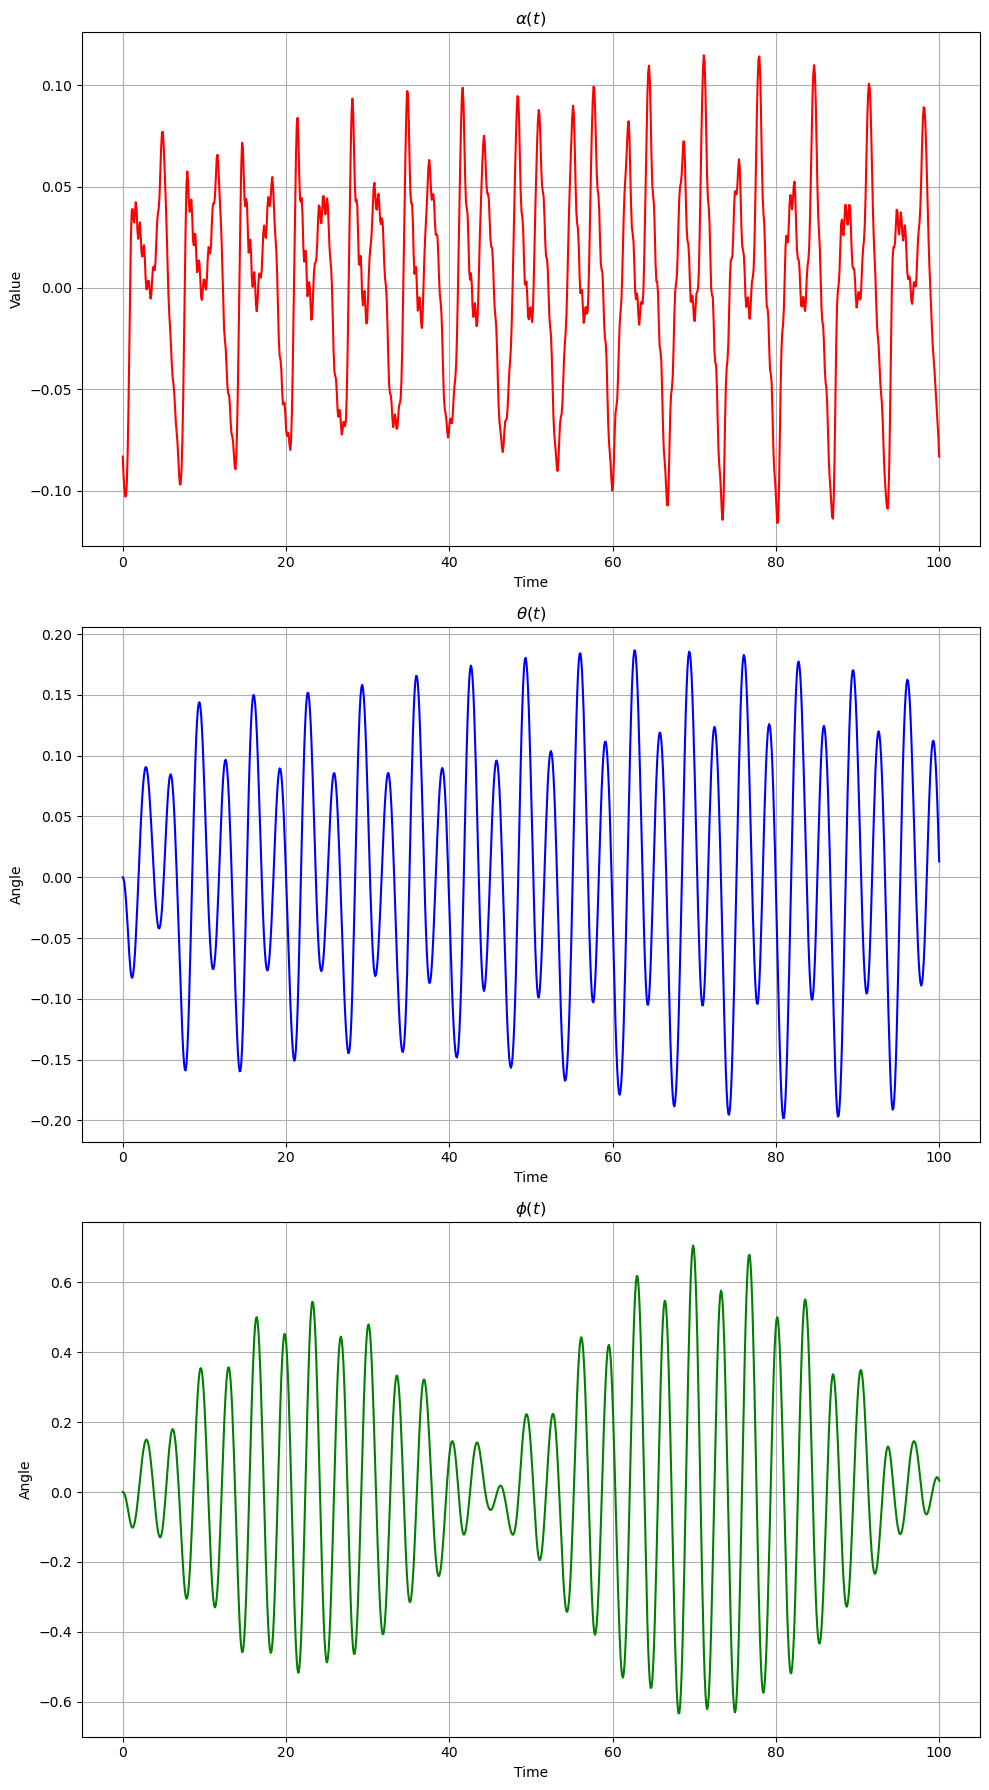

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import pandas as pd

# Load the data
file_path = r'C:\Users\ss4432\study\theta_t - theta_t.csv'
data = pd.read_csv(file_path)

# Extract the relevant part of the data
end_data = data.iloc[90000:].reset_index(drop=True)
input_data = np.array([[row[0] - 900, row[1]] for row in end_data.values])

# Create an interpolation function
interp = interp1d(input_data[:, 0], input_data[:, 1], kind='linear', fill_value="extrapolate")

# Define the alpha function
def alpha(t):
    return interp(t)

# Define the parameters
a = 1
b = 0.9
c = 0.1
M = 10
m = 1
II = 10
g = 10
omega = 2 * np.pi * 0.3
k = 100
EE = 0.000001
d = 6
theta_max = 0.3
C1 = 10
lambda_phi = 0.0003

# Dimensionless parameters
m1 = m / M
II1 = II / (M * a**2)
g1 = g / (a * omega**2)
k1 = k / (M * a**2 * omega**2)
EE1 = EE / (M * a**2 * omega**2)
nu1 = C1 / (M * a**2 * omega)
lambda1 = lambda_phi / (M * a**2 * omega)
b1 = b / a
c1 = c / a

# Potential energy function
def U(theta):
    return EE1 * (1 / (theta - theta_max)**d + 1 / (theta + theta_max)**d)

# Define the system of ODEs
def system(t, y):
    theta, phi, theta_dot, phi_dot = y
    
    # Calculate the second derivatives based on the provided equations
    d2theta = (-m1 * g1 * np.sin(theta) - k1 * (theta - alpha(t)) - nu1 * theta_dot) / II1
    d2phi = (-m1 * g1 * np.sin(phi) - k1 * (phi - alpha(t)) - lambda1 * phi_dot) / II1
    
    return [theta_dot, phi_dot, d2theta, d2phi]

# Initial conditions
ics = [0, 0, 0, 0]

# Time points
t_span = (0, 100)
t_values = np.linspace(*t_span, 1000)

# Solve the system
sol = solve_ivp(system, t_span, ics, t_eval=t_values, method='RK45', vectorized=True)

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot alpha(t)
axs[0].plot(t_values, alpha(t_values), color='red')
axs[0].set_title(r'$\alpha(t)$')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Value')
axs[0].grid(True)

# Plot theta(t)
axs[1].plot(sol.t, sol.y[0], color='blue')
axs[1].set_title(r'$\theta(t)$')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Angle')
axs[1].grid(True)

# Plot phi(t)
axs[2].plot(sol.t, sol.y[1], color='green')
axs[2].set_title(r'$\phi(t)$')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Angle')
axs[2].grid(True)

plt.tight_layout()
plt.show()


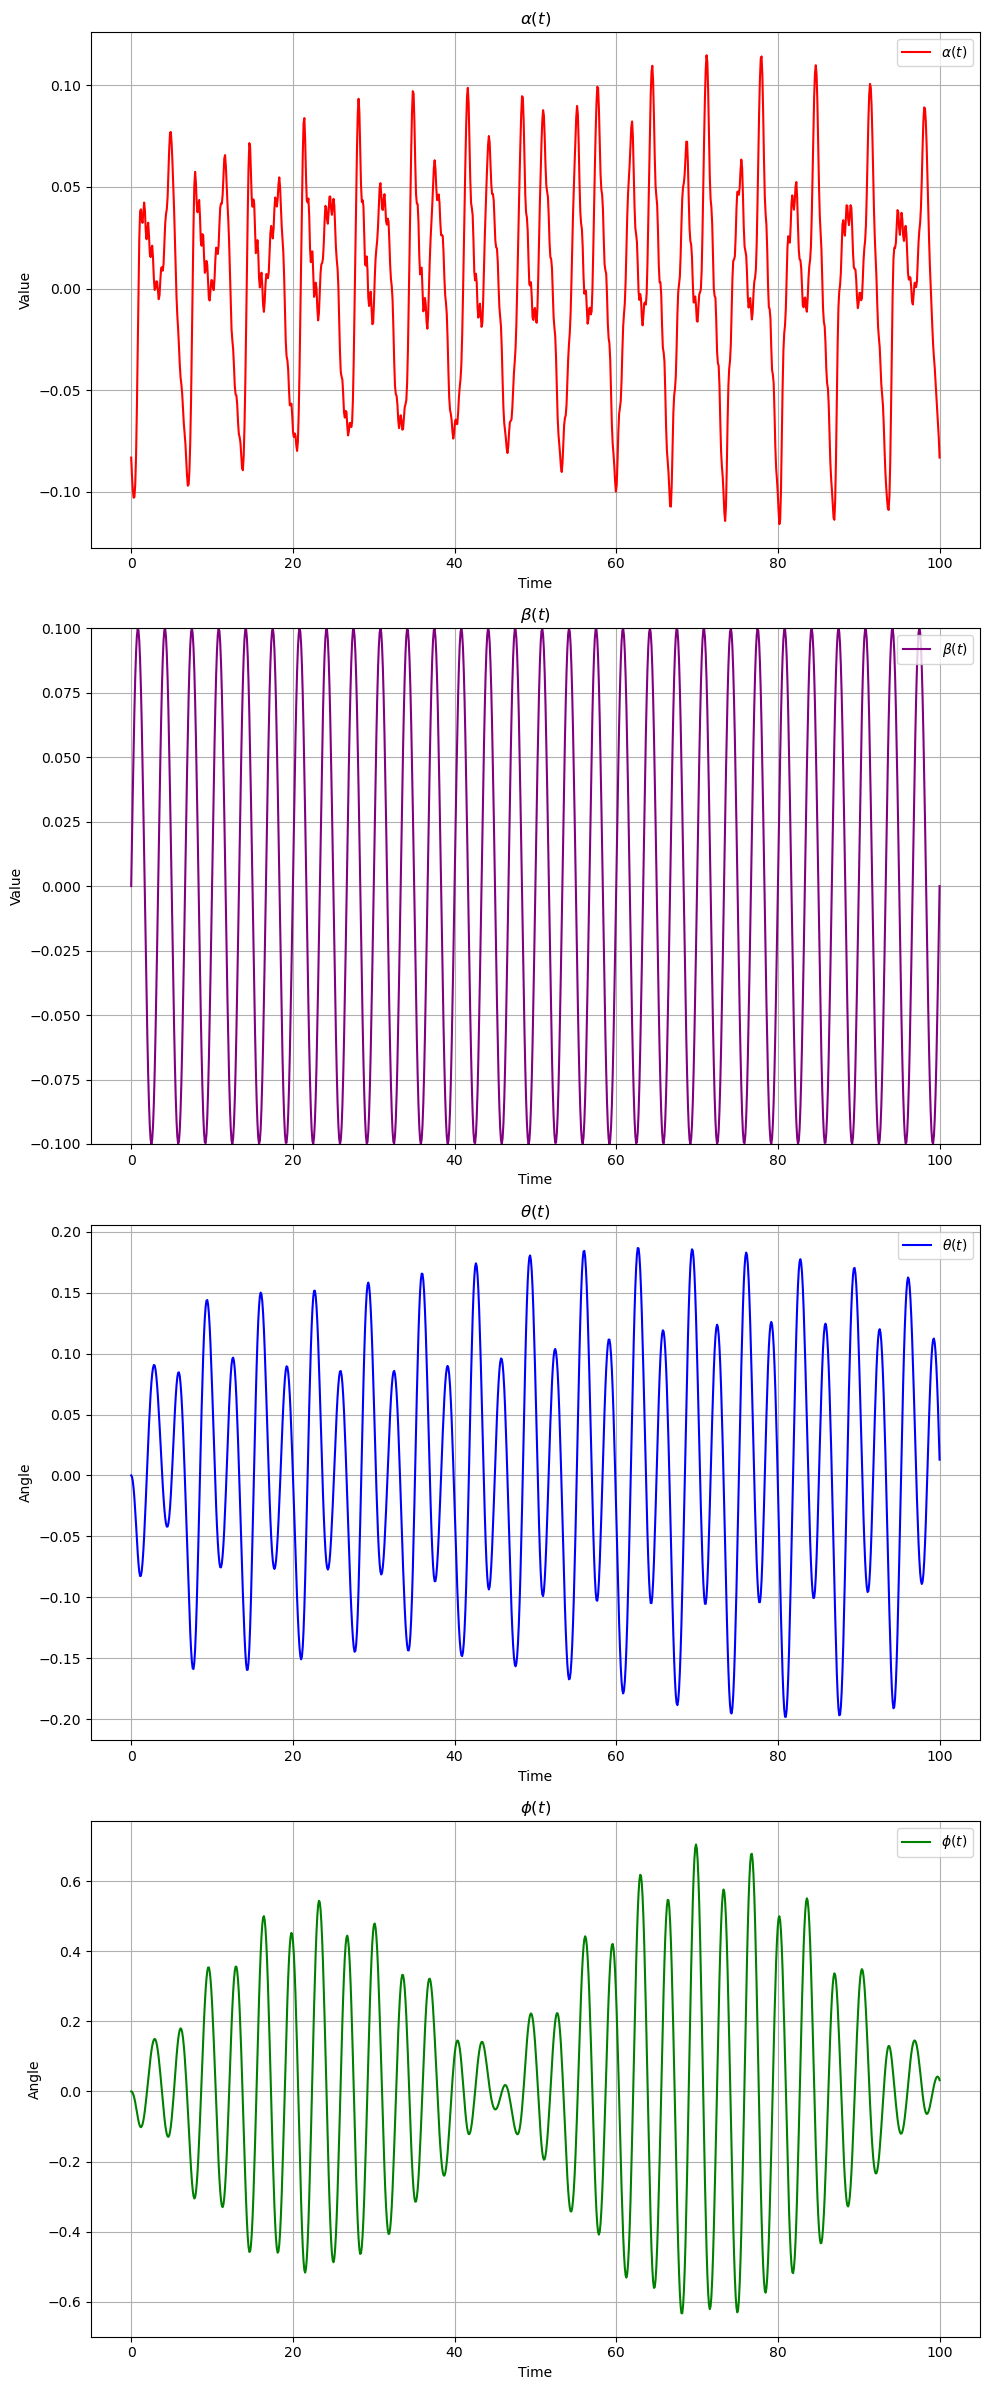

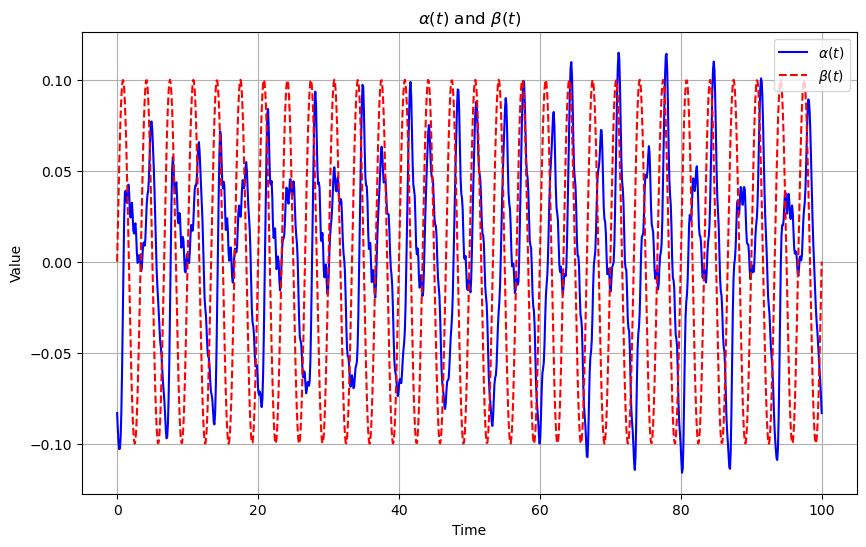

In [5]:
# Adjust the plotting to have a higher range for alpha and a smaller range for beta
A = 0.1  # Adjusted amplitude of β oscillations

def beta(t):
    return A * np.sin(omega * t)

# Solve the system again with the adjusted beta
sol = solve_ivp(system, t_span, ics, t_eval=t_values, method='RK45', vectorized=True)

# Create subplots for comparison with adjusted beta range
fig, axs = plt.subplots(4, 1, figsize=(10, 24))

# Plot alpha(t) with a higher range
axs[0].plot(t_values, alpha(t_values), color='red', label=r'$\alpha(t)$')
axs[0].set_title(r'$\alpha(t)$')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Value')
axs[0].legend()
axs[0].grid(True)

# Plot beta(t) with adjusted range
axs[1].plot(t_values, beta(t_values), color='purple', label=r'$\beta(t)$')
axs[1].set_ylim(-0.1, 0.1)
axs[1].set_title(r'$\beta(t)$')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Value')
axs[1].legend()
axs[1].grid(True)

# Plot theta(t)
axs[2].plot(sol.t, sol.y[0], color='blue', label=r'$\theta(t)$')
axs[2].set_title(r'$\theta(t)$')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Angle')
axs[2].legend()
axs[2].grid(True)

# Plot phi(t)
axs[3].plot(sol.t, sol.y[1], color='green', label=r'$\phi(t)$')
axs[3].set_title(r'$\phi(t)$')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('Angle')
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()

# Overlay plot for α(t) and β(t) for direct comparison with adjusted beta range
plt.figure(figsize=(10, 6))
plt.plot(t_values, alpha(t_values), label=r'$\alpha(t)$', color='blue')
plt.plot(t_values, beta(t_values), label=r'$\beta(t)$', color='red', linestyle='--')
plt.title(r'$\alpha(t)$ and $\beta(t)$')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
from scipy.fft import fft, fftfreq

# Define objective function
def objective(params):
    k1, nu1, lambda1 = params
    
    # Redefine the system with new parameters
    def system(t, y):
        theta, phi, theta_dot, phi_dot = y
        d2theta = (-m1 * g1 * np.sin(theta) - k1 * (theta - alpha(t)) - nu1 * theta_dot) / II1
        d2phi = (-m1 * g1 * np.sin(phi) - k1 * (phi - beta(t)) - lambda1 * phi_dot) / II1
        return [theta_dot, phi_dot, d2theta, d2phi]
    
    # Solve the system
    sol = solve_ivp(system, t_span, ics, t_eval=t_values, method='RK45', vectorized=True)
    
    # Fourier transform of phi(t)
    phi_fft = fft(sol.y[1])
    freq = fftfreq(len(t_values), (t_values[1] - t_values[0]))
    
    # Objective: Sum of the squares of the high-frequency components
    high_freq_components = np.abs(phi_fft[freq > 1.2])  
    return -np.sum(high_freq_components**2)

# Initial parameter guess
initial_params = [k1, nu1, lambda1]

# Optimization
from scipy.optimize import minimize

result = minimize(objective, initial_params, method='Nelder-Mead')

optimized_params = result.x
print("Optimized parameters:", optimized_params)


Optimized parameters: [2.93290829e+00 5.36997475e-01 1.54167212e-05]


In [15]:
# Use optimized parameters
k1_opt, nu1_opt, lambda1_opt, omega_opt = optimized_params

# Redefine the system with optimized parameters
def optimized_system(t, y):
    theta, phi, theta_dot, phi_dot = y
    d2theta = (-m1 * g1 * np.sin(theta) - k1_opt * (theta - alpha(t)) - nu1_opt * theta_dot) / II1
    d2phi = (-m1 * g1 * np.sin(phi) - k1_opt * (phi - beta(t)) - lambda1_opt * phi_dot) / II1
    return [theta_dot, phi_dot, d2theta, d2phi]

# Solve the optimized system
sol_opt = solve_ivp(optimized_system, t_span, ics, t_eval=t_values, method='RK45', vectorized=True)

# Plot the results
fig, axs = plt.subplots(4, 1, figsize=(10, 24))

# Plot alpha(t)
axs[0].plot(t_values, alpha(t_values), color='red', label=r'$\alpha(t)$')
axs[0].set_ylim(-0.5, 0.5)
axs[0].set_xlim(0, 100)
axs[0].set_title(r'$\alpha(t)$')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Value')
axs[0].legend()
axs[0].grid(True)

# Plot beta(t) with adjusted range
axs[1].plot(t_values, beta(t_values), color='purple', label=r'$\beta(t)$')
axs[1].set_ylim(-0.1, 0.1)
axs[1].set_xlim(0, 100)
axs[1].set_title(r'$\beta(t)$')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Value')
axs[1].legend()
axs[1].grid(True)

# Plot theta(t)
axs[2].plot(sol_opt.t, sol_opt.y[0], color='blue', label=r'$\theta(t)$')
axs[2].set_ylim(-0.5, 0.5)
axs[2].set_xlim(0, 700)
axs[2].set_title(r'$\theta(t)$')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Angle')
axs[2].legend()
axs[2].grid(True)

# Plot phi(t)
axs[3].plot(sol_opt.t, sol_opt.y[1], color='green', label=r'$\phi(t)$')
axs[3].set_ylim(-5.0, 5.0)
axs[3].set_xlim(0, 100)
axs[3].set_title(r'$\phi(t)$')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('Angle')
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 4, got 3)

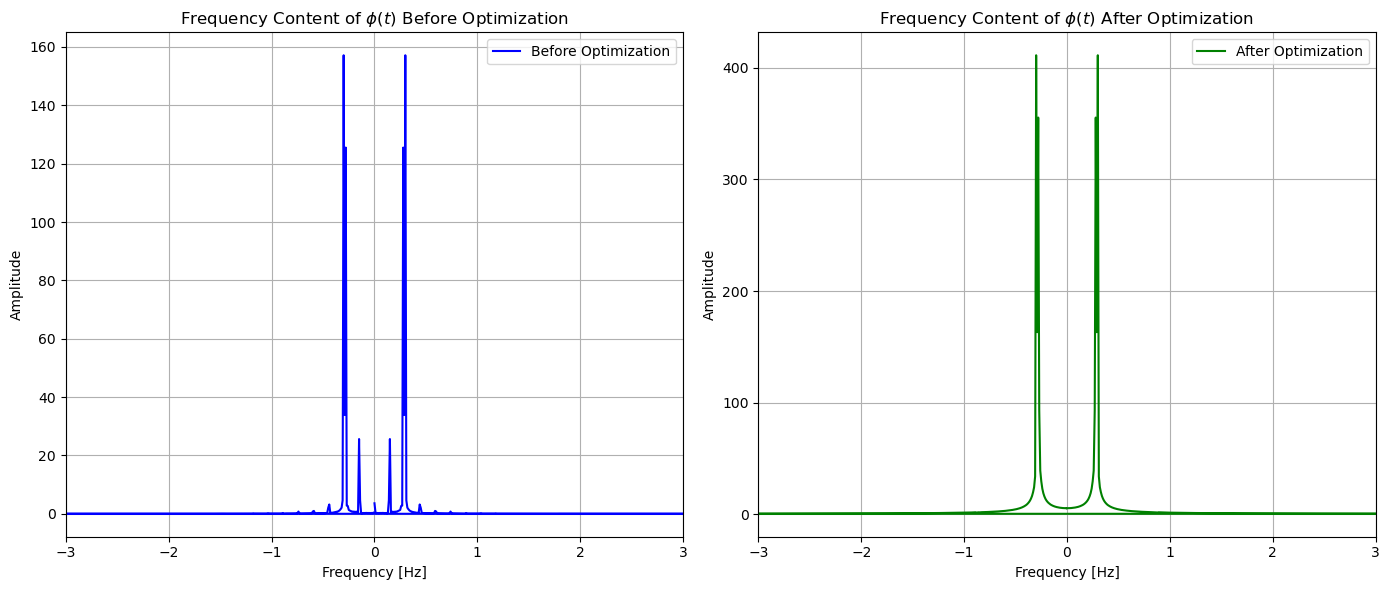

In [16]:
# Fourier transform of phi(t) before optimization
phi_fft_before = fft(sol.y[1])
freq_before = fftfreq(len(t_values), (t_values[1] - t_values[0]))

# Fourier transform of phi(t) after optimization
phi_fft_after = fft(sol_opt.y[1])
freq_after = fftfreq(len(t_values), (t_values[1] - t_values[0]))

# Plotting the frequency content
plt.figure(figsize=(14, 6))

# Zoom in on the low-frequency region
zoom_range = (-3, 3)

plt.subplot(1, 2, 1)
plt.plot(freq_before, np.abs(phi_fft_before), label='Before Optimization', color='blue')
plt.xlim(zoom_range)
plt.title('Frequency Content of $\phi(t)$ Before Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freq_after, np.abs(phi_fft_after), label='After Optimization', color='green')
plt.xlim(zoom_range)
plt.title('Frequency Content of $\phi(t)$ After Optimization ')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


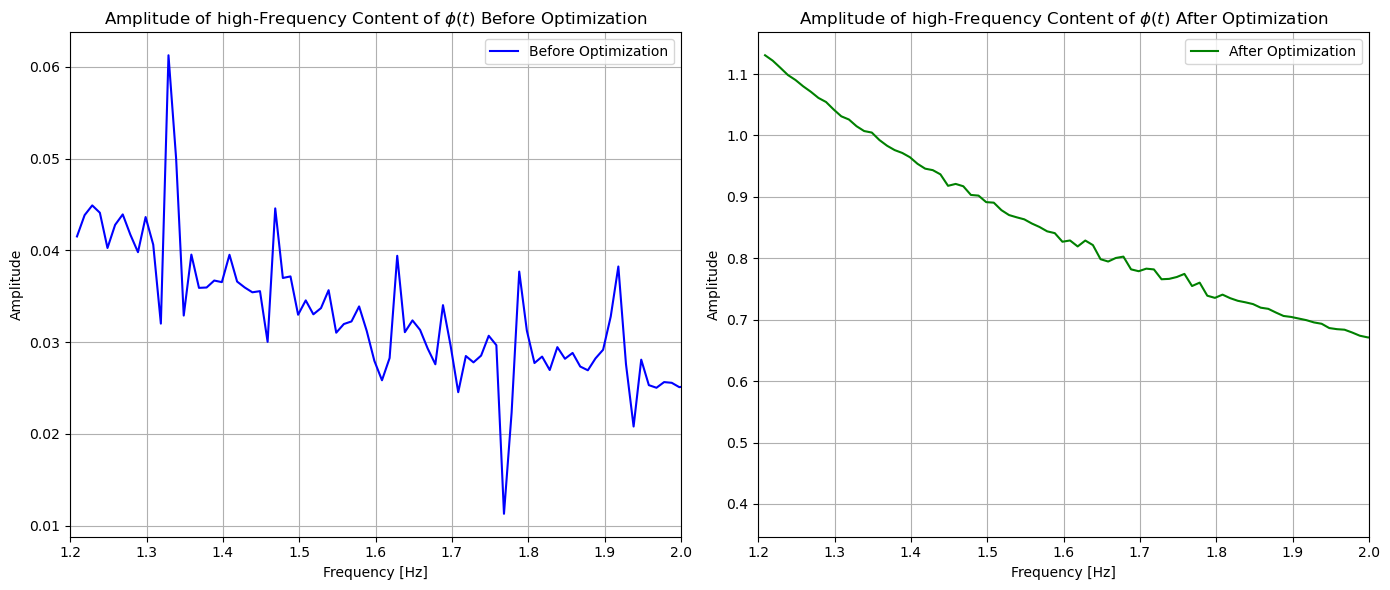

In [17]:
# Plotting the high-frequency content of phi(t)
# Fourier transform of phi(t) before optimization
phi_fft_before = fft(sol.y[1])
freq_before = fftfreq(len(t_values), (t_values[1] - t_values[0]))

# Fourier transform of phi(t) after optimization
phi_fft_after = fft(sol_opt.y[1])
freq_after = fftfreq(len(t_values), (t_values[1] - t_values[0]))
high_freq_limit = 1.2  # Frequency threshold in Hz

plt.figure(figsize=(14, 6))

# Zoom in on the low-frequency region
zoom_range = (1.2, 2.0)


# Define the range for high frequencies
high_freq_range = (freq_before > high_freq_limit)

# Plot for before optimization
plt.subplot(1, 2, 1)
plt.plot(freq_before[high_freq_range], np.abs(phi_fft_before)[high_freq_range], label='Before Optimization', color='blue')
plt.xlim(zoom_range)
plt.title('Amplitude of high-Frequency Content of $\phi(t)$ Before Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Plot for after optimization
plt.subplot(1, 2, 2)
plt.plot(freq_after[high_freq_range], np.abs(phi_fft_after)[high_freq_range], label='After Optimization', color='green')
plt.xlim(zoom_range)
plt.title('Amplitude of high-Frequency Content of $\phi(t)$ After Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [10]:
# Calculate the sum of the high-frequency components' amplitudes
high_freq_before_sum = np.sum(np.abs(phi_fft_before)[high_freq_range])
high_freq_after_sum = np.sum(np.abs(phi_fft_after)[high_freq_range])

print(f"Sum of high-frequency components before optimization: {high_freq_before_sum}")
print(f"Sum of high-frequency components after optimization: {high_freq_after_sum}")


Sum of high-frequency components before optimization: 7.749080300366506
Sum of high-frequency components after optimization: 206.4270238248849


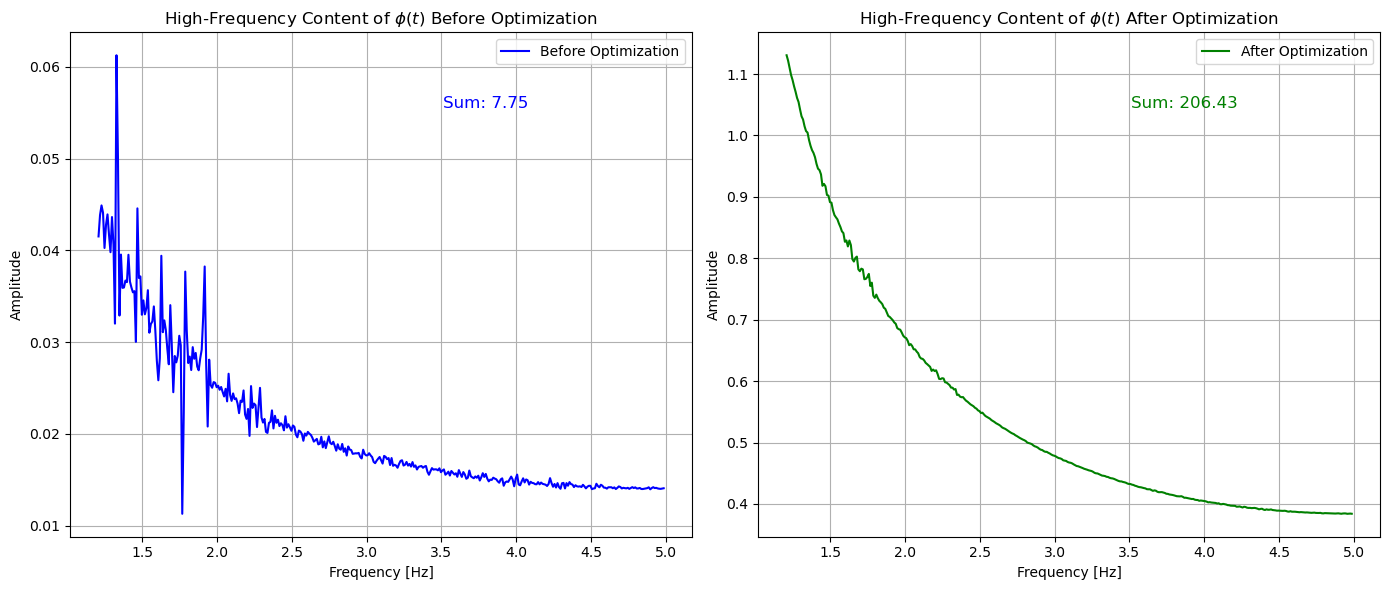

In [11]:
# Define the range for high frequencies
high_freq_limit = 1.2  # Frequency threshold in Hz
high_freq_range_before = (freq_before > high_freq_limit)
high_freq_range_after = (freq_after > high_freq_limit)
# Generate plots for high-frequency components before and after optimization
plt.figure(figsize=(14, 6))

# Plot for before optimization
plt.subplot(1, 2, 1)
plt.plot(freq_before[high_freq_range_before], np.abs(phi_fft_before)[high_freq_range_before], label='Before Optimization', color='blue')
plt.title('High-Frequency Content of $\phi(t)$ Before Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.annotate(f'Sum: {high_freq_before_sum:.2f}', xy=(0.6, 0.85), xycoords='axes fraction', fontsize=12, color='blue')

# Plot for after optimization
plt.subplot(1, 2, 2)
plt.plot(freq_after[high_freq_range_after], np.abs(phi_fft_after)[high_freq_range_after], label='After Optimization', color='green')
plt.title('High-Frequency Content of $\phi(t)$ After Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.annotate(f'Sum: {high_freq_after_sum:.2f}', xy=(0.6, 0.85), xycoords='axes fraction', fontsize=12, color='green')

plt.tight_layout()
plt.show()


Noise level before optimization: 0.007865936458321005
Noise level after optimization: 0.18526213061920058


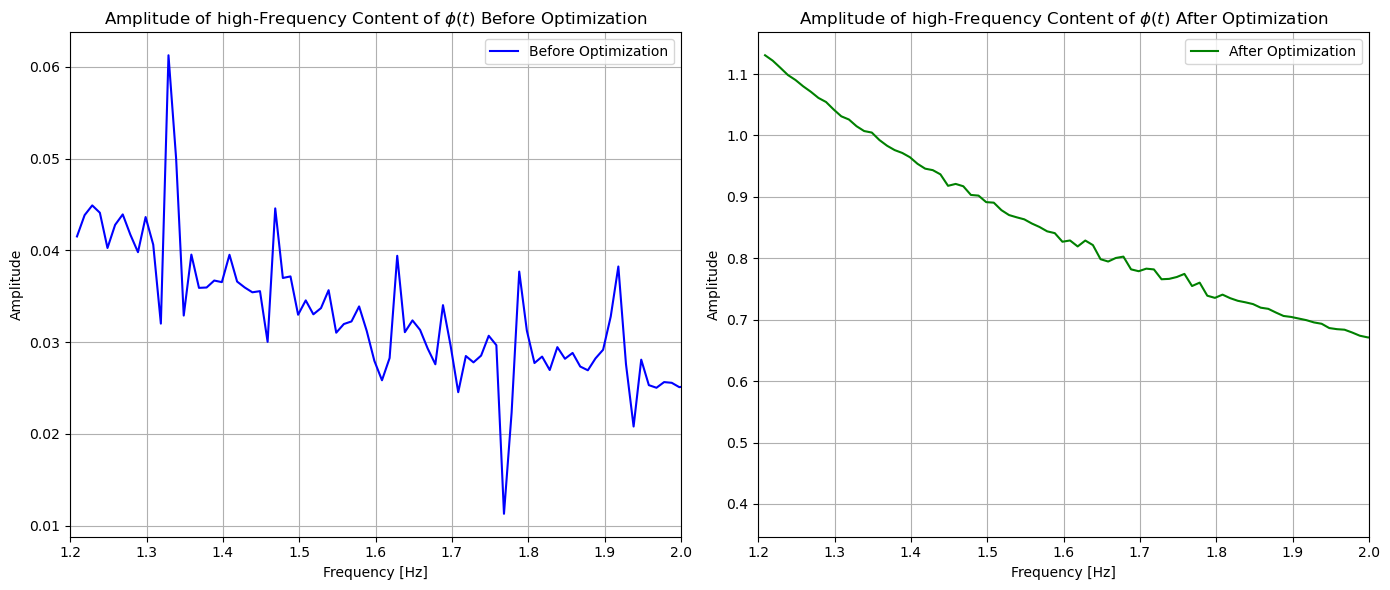

In [12]:

# Calculate the standard deviation of the amplitude in the high-frequency range
noise_before = np.std(np.abs(phi_fft_before)[high_freq_range_before])
noise_after = np.std(np.abs(phi_fft_after)[high_freq_range_after])

print(f"Noise level before optimization: {noise_before}")
print(f"Noise level after optimization: {noise_after}")

# Plot the high-frequency content of phi(t)
plt.figure(figsize=(14, 6))

# Define zoom range for plotting
zoom_range = (1.2, 2.0)

# Plot for before optimization
plt.subplot(1, 2, 1)
plt.plot(freq_before[high_freq_range_before], np.abs(phi_fft_before)[high_freq_range_before], label='Before Optimization', color='blue')
plt.xlim(zoom_range)
plt.title('Amplitude of high-Frequency Content of $\phi(t)$ Before Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Plot for after optimization
plt.subplot(1, 2, 2)
plt.plot(freq_after[high_freq_range_after], np.abs(phi_fft_after)[high_freq_range_after], label='After Optimization', color='green')
plt.xlim(zoom_range)
plt.title('Amplitude of high-Frequency Content of $\phi(t)$ After Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Absolute noise level before optimization: 0.007865936458321005
Absolute noise level after optimization: 0.18526213061920058
Relative noise level before optimization: 0.38471532132176517
Relative noise level after optimization: 0.3401412576884356


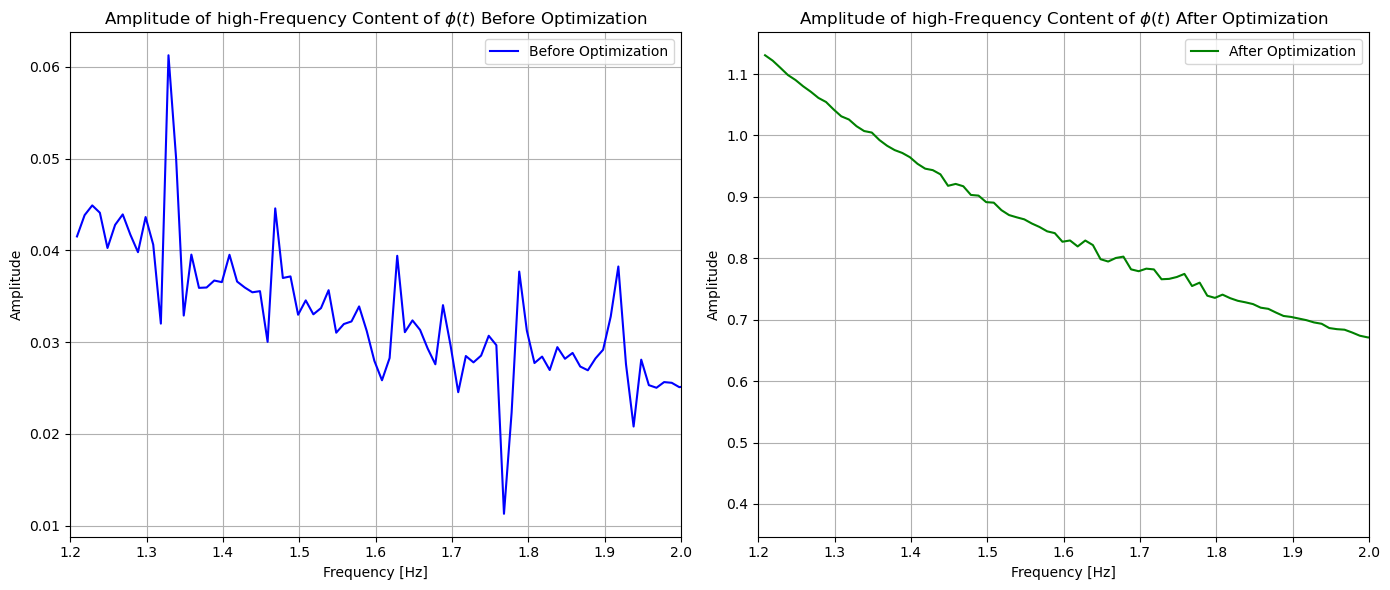

In [13]:
# Calculate the standard deviation (absolute noise) of the amplitude in the high-frequency range
absolute_noise_before = np.std(np.abs(phi_fft_before)[high_freq_range_before])
absolute_noise_after = np.std(np.abs(phi_fft_after)[high_freq_range_after])

# Calculate the mean amplitude in the high-frequency range
mean_amplitude_before = np.mean(np.abs(phi_fft_before)[high_freq_range_before])
mean_amplitude_after = np.mean(np.abs(phi_fft_after)[high_freq_range_after])

# Calculate the relative standard deviation (relative noise) of the amplitude in the high-frequency range
relative_noise_before = absolute_noise_before / mean_amplitude_before
relative_noise_after = absolute_noise_after / mean_amplitude_after

print(f"Absolute noise level before optimization: {absolute_noise_before}")
print(f"Absolute noise level after optimization: {absolute_noise_after}")
print(f"Relative noise level before optimization: {relative_noise_before}")
print(f"Relative noise level after optimization: {relative_noise_after}")

# Plot the high-frequency content of phi(t)
plt.figure(figsize=(14, 6))

# Define zoom range for plotting
zoom_range = (1.2, 2.0)

# Plot for before optimization
plt.subplot(1, 2, 1)
plt.plot(freq_before[high_freq_range_before], np.abs(phi_fft_before)[high_freq_range_before], label='Before Optimization', color='blue')
plt.xlim(zoom_range)
plt.title('Amplitude of high-Frequency Content of $\phi(t)$ Before Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Plot for after optimization
plt.subplot(1, 2, 2)
plt.plot(freq_after[high_freq_range_after], np.abs(phi_fft_after)[high_freq_range_after], label='After Optimization', color='green')
plt.xlim(zoom_range)
plt.title('Amplitude of high-Frequency Content of $\phi(t)$ After Optimization')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()